# Is het verdamping?

In dit experiment is er een verwarmingselement in een met water gevulde maatbeker gestopt. Elke minuut is de temperatuur van het water gemeten. Deze metingen zijn opgeslagen in [tempmetingen.csv](tempmetingen.csv).

Verder is gegeven dat: 
$m_{maatbeker} = 820.8 \mathrm{gr}$  
$m_{maatbeker + water, start} = 1292.9 \mathrm{gr}$  
$m_{maatbeker + water, eind} = 1274.9 \mathrm{gr}$

Het moge duidelijk zijn dat er water is 'verdwenen'. Ook is de eindtemperatuur van het water niet gelijk aan een proces waarbij verdamping en eventuele warmteverliezen niet meegenomen worden. 

```{exercise}
Onderzoek het proces door:
1. De plot van de metingen te maken, inclusief een verwachte trendlijn voor de temperatuur van het water als al de toegevoerde warmte gaat zitten in het water.
2. Bepaal of de totale hoeveelheid toegevoegde energie correspondeert met de opwarming en verdamping van het water, geef daarbij de aannames die je doet.
3. Geef aanbevelingen voor een verbetering van het experiment om (nog) beter het thermodynamische proces te kunnen onderzoeken en beschrijven.
```

In [2]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('tempmetingen.csv', delimiter=';',skiprows=1)
t = data[:,0]               # Gemeten tijd in minuten
T = data[:,1]               # Gemeten temperatuur in graden Celsius

m_maatbeker = 820.8         # Massa van de maatbeker in gram
totale_m_b = 1292.9         # Massa van de maatbeker + water aan het begin in gram
totale_m_e = 1274.9         # Massa van de maatbeker + water aan het eind in gram

m_b = (totale_m_b - m_maatbeker)/1000 # Massa van het water aan het begin in kg.
m_e = (totale_m_e - m_maatbeker)/1000 # Massa van het water aan het eind in kg.

c_water = 4180              # Soortelijke warmte van water in J/(kg K)
L_v = 2.26e6                # Latente verdampingswarmte van water in J/kg

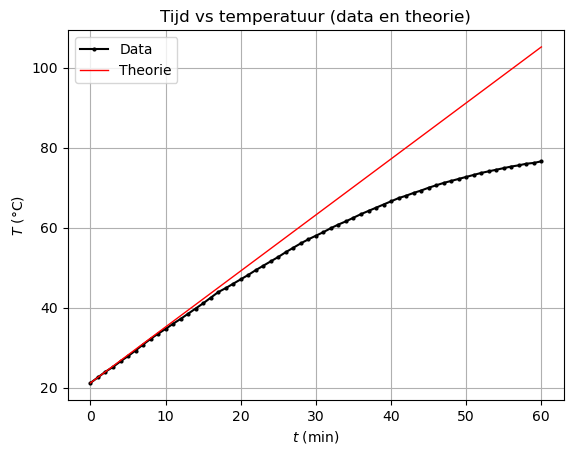

In [3]:
# Het maken van een theoretische array adhv de kleinste waarden van de gemeten waarden.
# De theorie gaat ervan uit dat alle toegevoerde warmte gaat zitten in het water;
        # Geen warmteverlies
        # Geen verdamping
        # Geen opwarming van de maatbeker

dT = T[1] - T[0]
dt = t[1] - t[0]

dTdt = dT / dt
T_theorie = T[0] + dTdt*t

plt.figure()
plt.title('Tijd vs temperatuur (data en theorie)')
plt.plot(t, T, '-o', ms=2, color='black', label='Data')
plt.plot(t, T_theorie, color='red', lw=1, label='Theorie')
plt.xlabel('$t$ (min)')
plt.ylabel('$T$ (°C)')
plt.legend()
plt.grid(True)
plt.show()

# In de figuur is goed te zien dat de gemeten (data) trendlijn een afnemende toename ondervindt door warmteverlies in tegenstelling tot de theoretische trendlijn waarbij geen warmteverlies plaatsvindt.
# De eindtemperatuur is ook lager bij de verkregen data dan bij de theoretische eindtemperatuur.

In [ ]:
E_theorie = (m_b * c_water * (T_theorie[-1] - T[0]))/1000

E_opwarming = (m_e * c_water * (T[-1]-T[0]))/1000
E_verdamping = ((m_b-m_e) * L_v)/1000

E_water = E_opwarming + E_verdamping

E_verschil = E_theorie - E_water

print(f'De totale hoeveelheid toegevoerde energie is {E_theorie:.1f} kJ.')
print(f'De opwarmings energie en de verdampings energie samen is {E_water:.1f} kJ.')
print(f'Het verschil in energie is {E_verschil:.1f} kJ.')

De totale hoeveelheid toegevoerde energie is 165.8 kJ.
De opwarmings energie en de verdampings energie samen is 145.8 kJ.
Het verschil in energie is 19.9 kJ.


Dit verschil in energie (~20 kJ) beslaat ~12% van de totale toegevoerde energie. De energie die nodig was voor het opwarmen en verdampen blijkt kleiner dan de totaal toegevoerde energie. Dit duidt op extra energieverlies, ter waarde van ~20 kJ. Dit verschil in energie wordt o.a. geleverd door de warmte die is afgegeven aan de omgeving.

Er is dus energie verloren gegaan aan de omgeving, wat ook te zien was in onze eerdere grafiek waarbij de gemeten eindtemperatuur lager uitviel dan de theoretische eindtemperatuur.


Onze aannames;
* Het vermogen blijft gedurende het hele experiment blijft constant;
* De soortelijke warmte van water is 4180 J/(kg K);
* De verdamping en het warmteverlies zijn niet precies gemeten;
* De massa van het water is homogeen gemengd.

Suggesties voor verbetering van het experiment;
* Isolatie van de maatbeter;
* Gebruik van een deksel;
* Temperatuur vaker meten dan elke minuut;
* Het vermogen van het verwarmingselement precies meten;
* Gebruik maken van een roerder voor in het water,